# Notebook 03 — Visualisasi
**Input**: `data/processed/demografi_clean.csv`  
**Output**: `output/figures/*.png`  
**Tujuan**: Membuat 6 visualisasi berkualitas publikasi untuk laporan dan portofolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Tema global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans'
})

FIGDIR = '../output/figures/'
PALETTE_PULAU = {
    'Jawa': '#2563EB',
    'Sumatera': '#16A34A',
    'Kalimantan': '#D97706',
    'Sulawesi': '#9333EA',
    'Papua/NTT/NTB': '#DC2626',
    'Lainnya': '#6B7280'
}

df = pd.read_csv('../data/processed/demografi_clean.csv')
print(f'Data loaded: {df.shape}')

Data loaded: (38, 27)


## Visualisasi 1 — Bar Chart: 15 Provinsi Terbesar (2026)

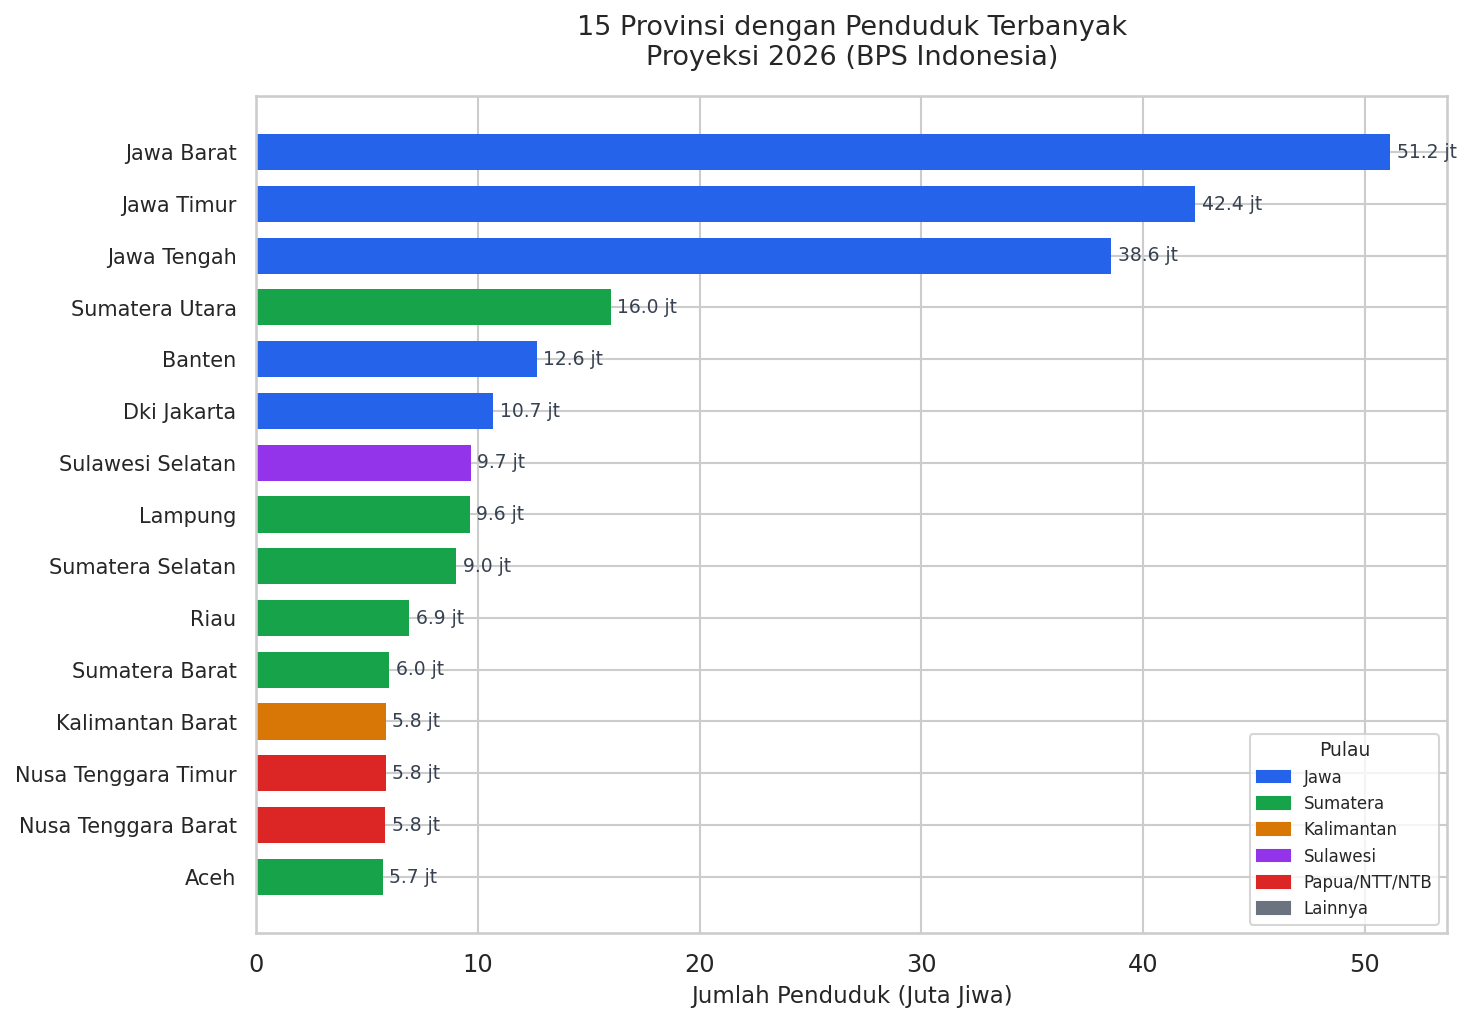

Saved: 01_top15_provinsi.png


In [2]:
top15 = df.nlargest(15, 'jumlah_penduduk_ribu_2026').copy()
top15['juta'] = top15['jumlah_penduduk_ribu_2026'] / 1000
colors = [PALETTE_PULAU.get(p, '#6B7280') for p in top15['pulau']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(top15)), top15['juta'], color=colors, edgecolor='none', height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['provinsi'].str.title(), fontsize=10)
ax.set_xlabel('Jumlah Penduduk (Juta Jiwa)', fontsize=11)
ax.set_title('15 Provinsi dengan Penduduk Terbanyak\nProyeksi 2026 (BPS Indonesia)', fontsize=13, pad=15)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}'))

for i, (bar, val) in enumerate(zip(bars, top15['juta'])):
    ax.text(val + 0.3, i, f'{val:.1f} jt', va='center', fontsize=9, color='#374151')

# Legend pulau
handles = [plt.Rectangle((0,0),1,1, color=c) for c in PALETTE_PULAU.values()]
ax.legend(handles, PALETTE_PULAU.keys(), title='Pulau', loc='lower right', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGDIR}01_top15_provinsi.png')
plt.show()
print('Saved: 01_top15_provinsi.png')

## Visualisasi 2 — Tren Laju Pertumbuhan Historis

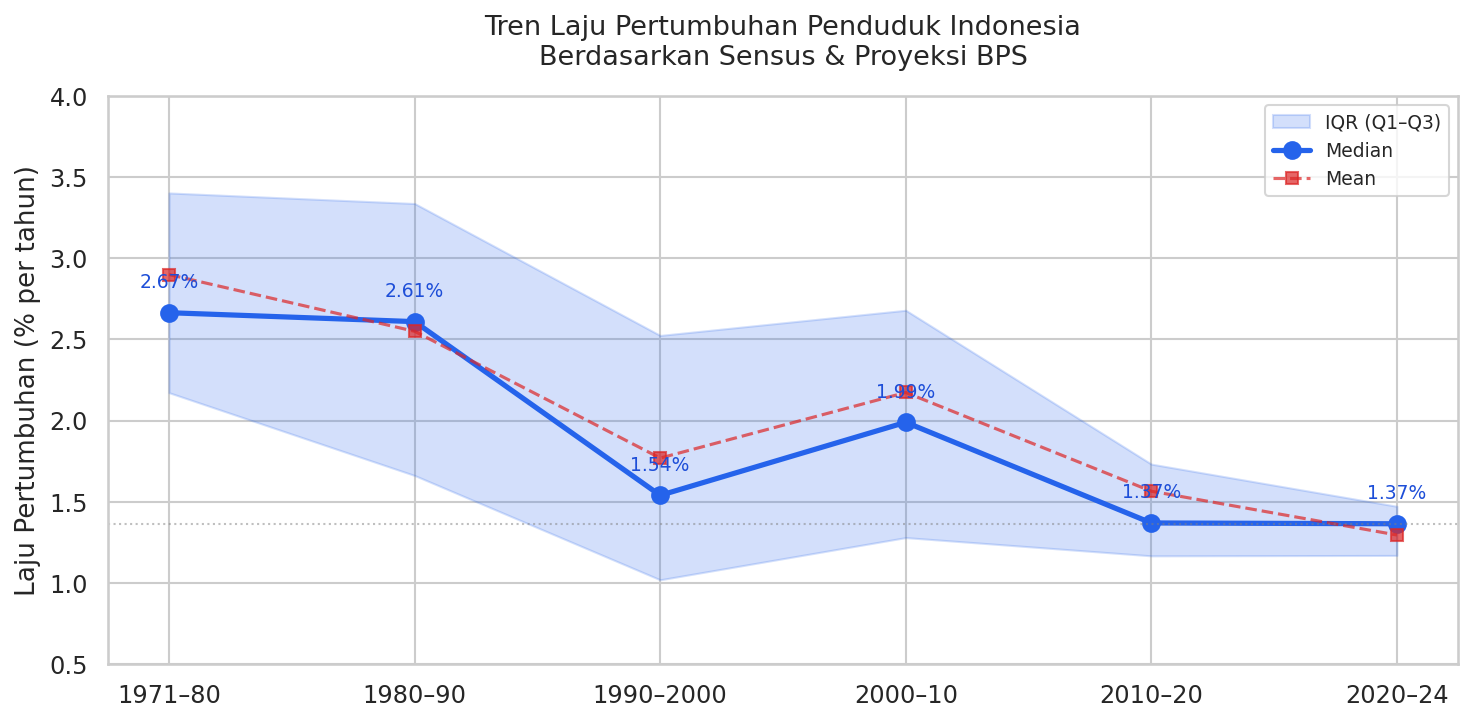

Saved: 02_tren_pertumbuhan.png


In [3]:
periodes = [
    ('1971–80', 'laju_1971_1980'), ('1980–90', 'laju_1980_1990'),
    ('1990–2000', 'laju_1990_2000'), ('2000–10', 'laju_2000_2010'),
    ('2010–20', 'laju_2010_2020'), ('2020–24', 'laju_2020_2024')
]

laju_data = []
for label, col in periodes:
    vals = df[col].dropna()
    laju_data.append({'periode': label, 'median': vals.median(), 'mean': vals.mean(),
                      'q1': vals.quantile(0.25), 'q3': vals.quantile(0.75)})
ldf = pd.DataFrame(laju_data)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(ldf.index, ldf['q1'], ldf['q3'], alpha=0.2, color='#2563EB', label='IQR (Q1–Q3)')
ax.plot(ldf.index, ldf['median'], 'o-', color='#2563EB', linewidth=2.5, markersize=8, label='Median')
ax.plot(ldf.index, ldf['mean'], 's--', color='#DC2626', linewidth=1.5, markersize=6, label='Mean', alpha=0.7)

for i, row in ldf.iterrows():
    ax.annotate(f"{row['median']:.2f}%", (i, row['median']), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=9, color='#1D4ED8')

ax.set_xticks(ldf.index)
ax.set_xticklabels(ldf['periode'])
ax.set_ylabel('Laju Pertumbuhan (% per tahun)')
ax.set_title('Tren Laju Pertumbuhan Penduduk Indonesia\nBerdasarkan Sensus & Proyeksi BPS', fontsize=13, pad=15)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 4)
ax.axhline(y=ldf['median'].iloc[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(f'{FIGDIR}02_tren_pertumbuhan.png')
plt.show()
print('Saved: 02_tren_pertumbuhan.png')

## Visualisasi 3 — Scatter Plot: Kepadatan vs IMR

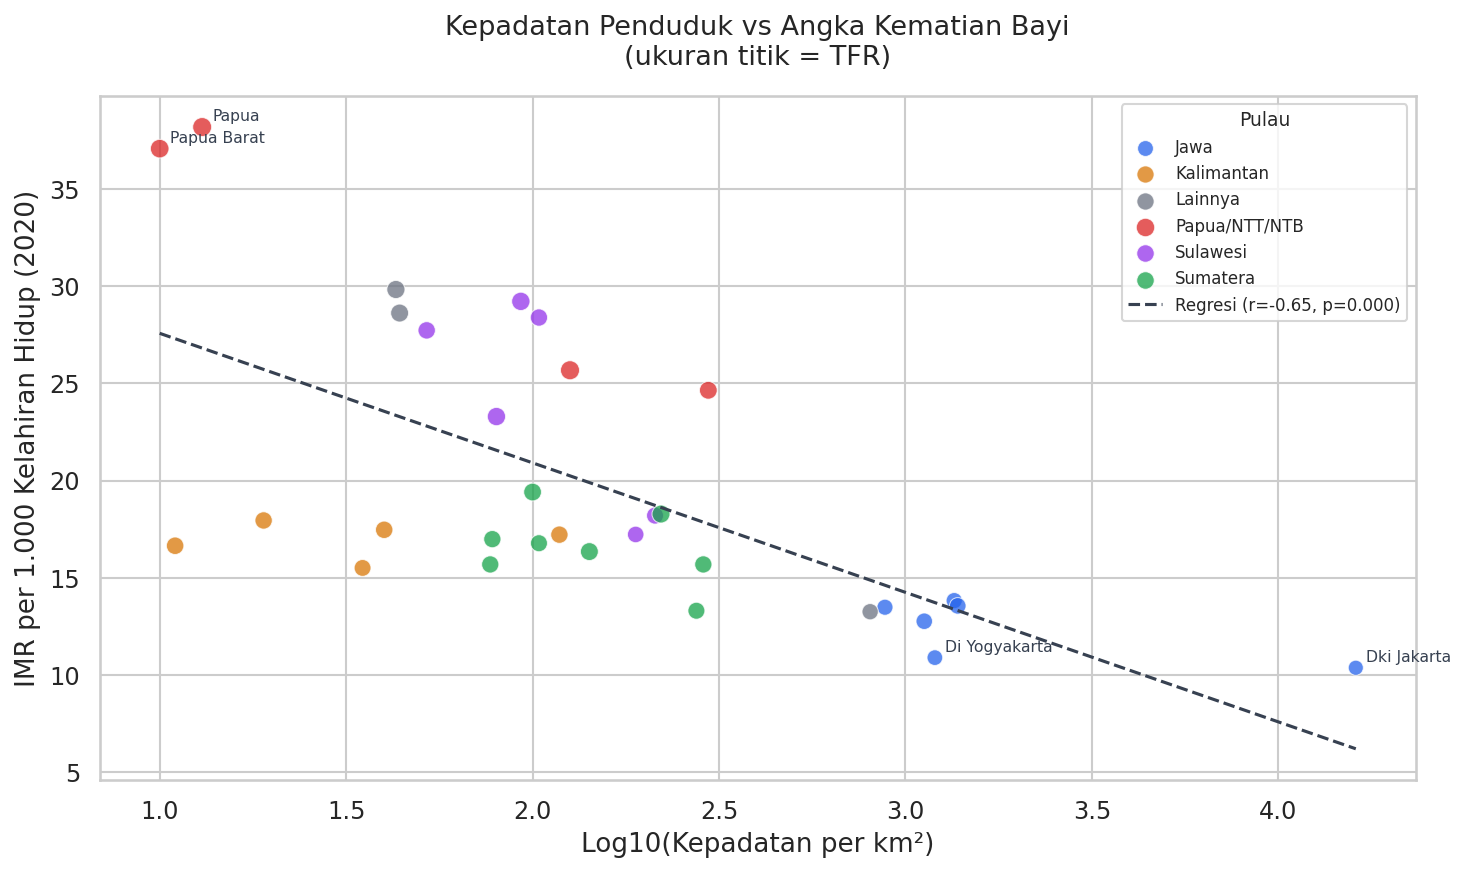

Saved: 03_scatter_kepadatan_imr.png


In [4]:
scatter_df = df[['provinsi','kepadatan_per_km2_2026','imr_per1000_2020','pulau','tfr_2020']].dropna()
scatter_df['log_kepadatan'] = np.log10(scatter_df['kepadatan_per_km2_2026'])

fig, ax = plt.subplots(figsize=(10, 6))

for pulau, grp in scatter_df.groupby('pulau'):
    ax.scatter(grp['log_kepadatan'], grp['imr_per1000_2020'],
               color=PALETTE_PULAU.get(pulau, '#6B7280'), s=grp['tfr_2020']*30,
               alpha=0.75, label=pulau, edgecolors='white', linewidths=0.5)

# Regression line
x = scatter_df['log_kepadatan']
y = scatter_df['imr_per1000_2020']
m, b, r, p, _ = stats.linregress(x, y)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline + b, color='#374151', linestyle='--', linewidth=1.5,
        label=f'Regresi (r={r:.2f}, p={p:.3f})')

# Label provinsi outlier
for _, row in scatter_df.iterrows():
    if row['imr_per1000_2020'] > 30 or row['imr_per1000_2020'] < 12:
        ax.annotate(row['provinsi'].title(), (row['log_kepadatan'], row['imr_per1000_2020']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5, color='#374151')

ax.set_xlabel('Log10(Kepadatan per km²)')
ax.set_ylabel('IMR per 1.000 Kelahiran Hidup (2020)')
ax.set_title('Kepadatan Penduduk vs Angka Kematian Bayi\n(ukuran titik = TFR)', fontsize=13, pad=15)
ax.legend(fontsize=8, title='Pulau', title_fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGDIR}03_scatter_kepadatan_imr.png')
plt.show()
print('Saved: 03_scatter_kepadatan_imr.png')

## Visualisasi 4 — Heatmap Korelasi

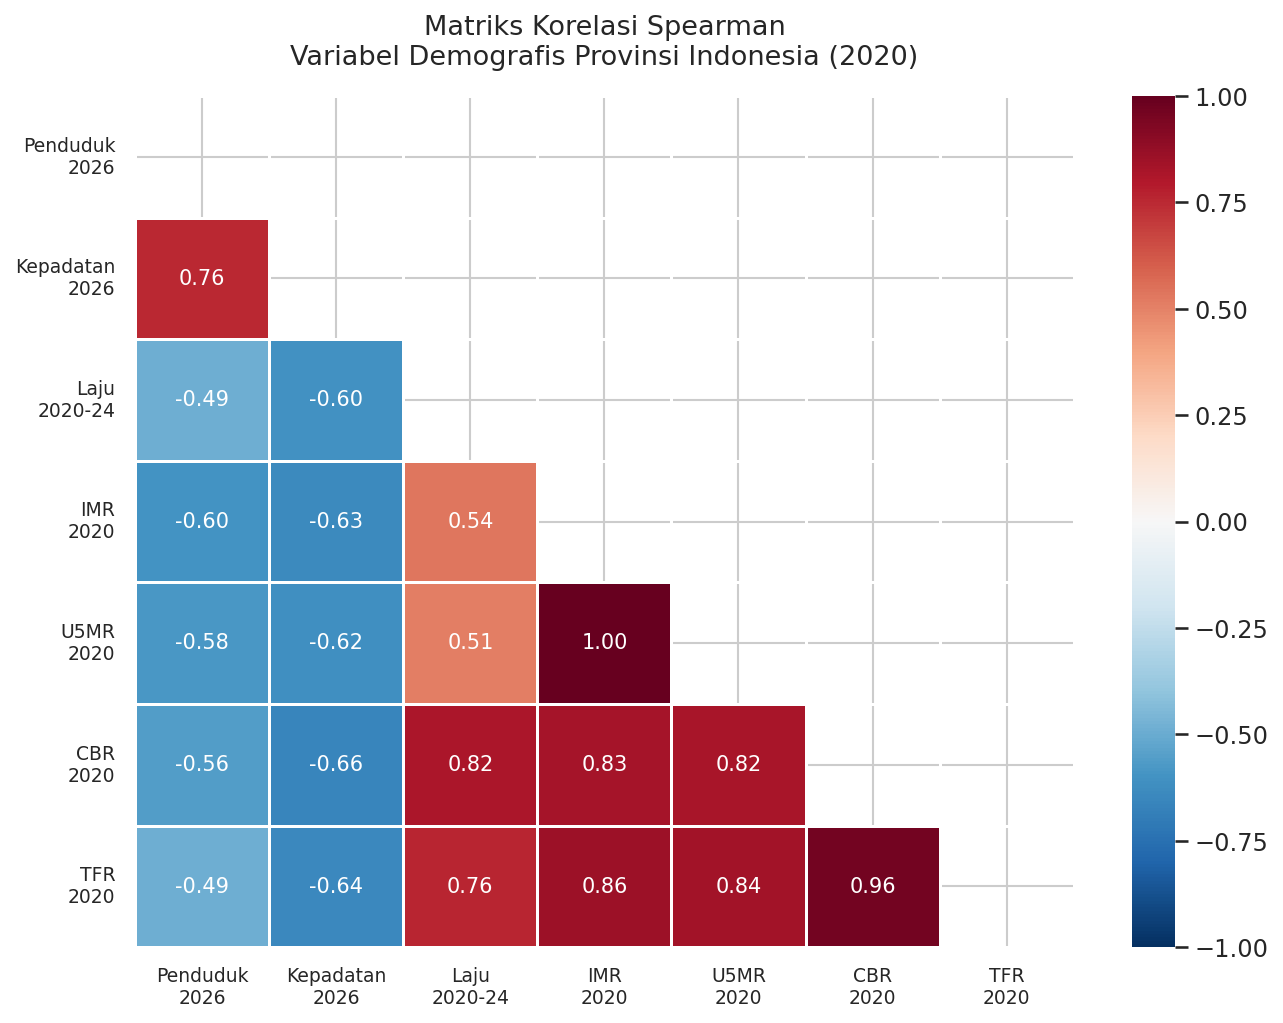

Saved: 04_heatmap_korelasi.png


In [5]:
corr_cols = [
    'jumlah_penduduk_ribu_2026', 'kepadatan_per_km2_2026', 'laju_2020_2024',
    'imr_per1000_2020', 'u5mr_per1000_2020', 'cbr_per1000_2020', 'tfr_2020'
]
labels = ['Penduduk\n2026', 'Kepadatan\n2026', 'Laju\n2020-24',
          'IMR\n2020', 'U5MR\n2020', 'CBR\n2020', 'TFR\n2020']

corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor='white', ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Matriks Korelasi Spearman\nVariabel Demografis Provinsi Indonesia (2020)', fontsize=13, pad=15)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGDIR}04_heatmap_korelasi.png')
plt.show()
print('Saved: 04_heatmap_korelasi.png')

## Visualisasi 5 — Box Plot Laju Pertumbuhan per Pulau

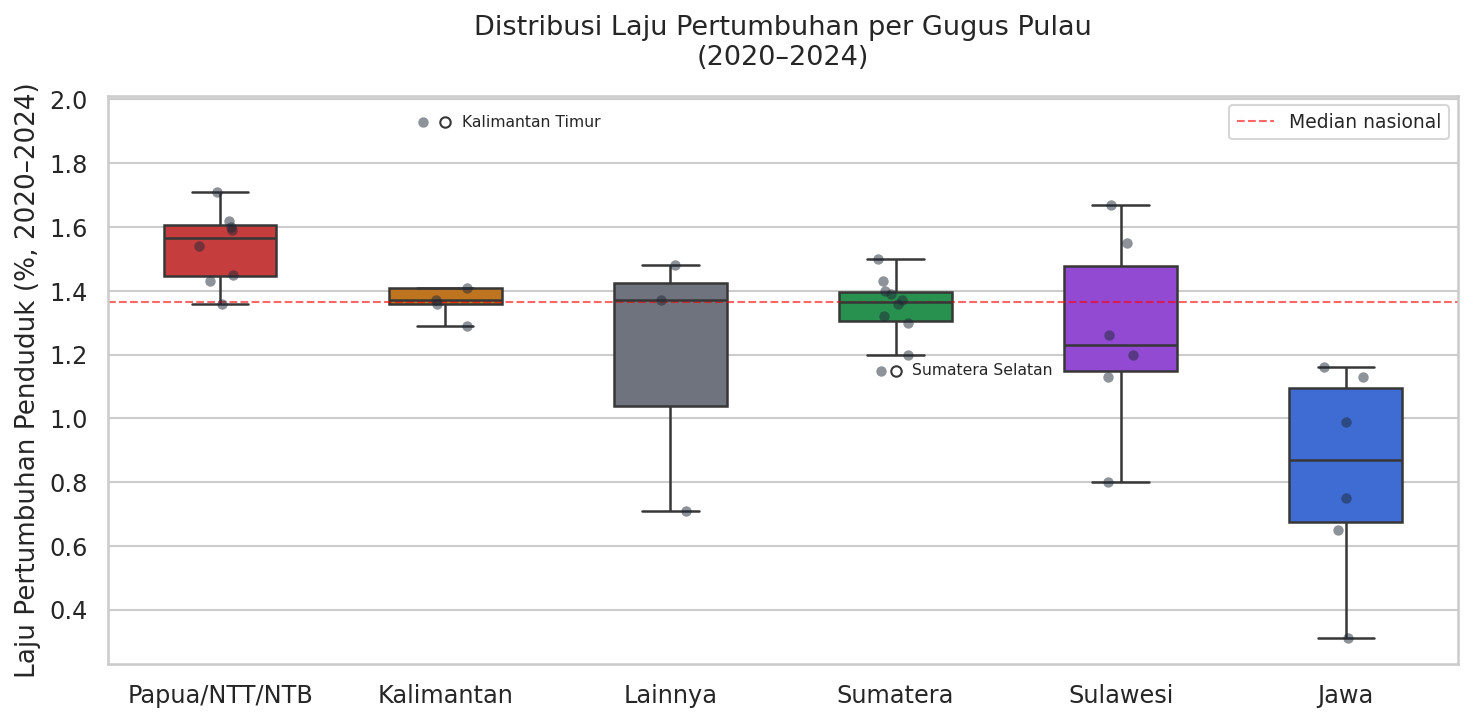

Saved: 05_boxplot_pertumbuhan_pulau.png


In [6]:
order = df.groupby('pulau')['laju_2020_2024'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
bp = sns.boxplot(
    data=df.dropna(subset=['laju_2020_2024']),
    x='pulau', y='laju_2020_2024', order=order,
    palette=[PALETTE_PULAU.get(p,'#6B7280') for p in order],
    width=0.5, linewidth=1.2, fliersize=5, ax=ax
)
sns.stripplot(
    data=df.dropna(subset=['laju_2020_2024']),
    x='pulau', y='laju_2020_2024', order=order,
    color='#1F2937', alpha=0.5, size=5, jitter=True, ax=ax
)

# Annotate provinsi outlier
for i, pulau in enumerate(order):
    grp = df[df['pulau'] == pulau].dropna(subset=['laju_2020_2024'])
    Q1 = grp['laju_2020_2024'].quantile(0.25)
    Q3 = grp['laju_2020_2024'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = grp[(grp['laju_2020_2024'] < Q1 - 1.5*IQR) | (grp['laju_2020_2024'] > Q3 + 1.5*IQR)]
    for _, row in outliers.iterrows():
        ax.annotate(row['provinsi'].title(), (i, row['laju_2020_2024']),
                    textcoords='offset points', xytext=(8, 0), fontsize=7.5, va='center')

ax.axhline(df['laju_2020_2024'].median(), color='red', linestyle='--', linewidth=1, alpha=0.6, label='Median nasional')
ax.set_xlabel('')
ax.set_ylabel('Laju Pertumbuhan Penduduk (%, 2020–2024)')
ax.set_title('Distribusi Laju Pertumbuhan per Gugus Pulau\n(2020–2024)', fontsize=13, pad=15)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGDIR}05_boxplot_pertumbuhan_pulau.png')
plt.show()
print('Saved: 05_boxplot_pertumbuhan_pulau.png')

## Visualisasi 6 — Dashboard 4-Panel Summary

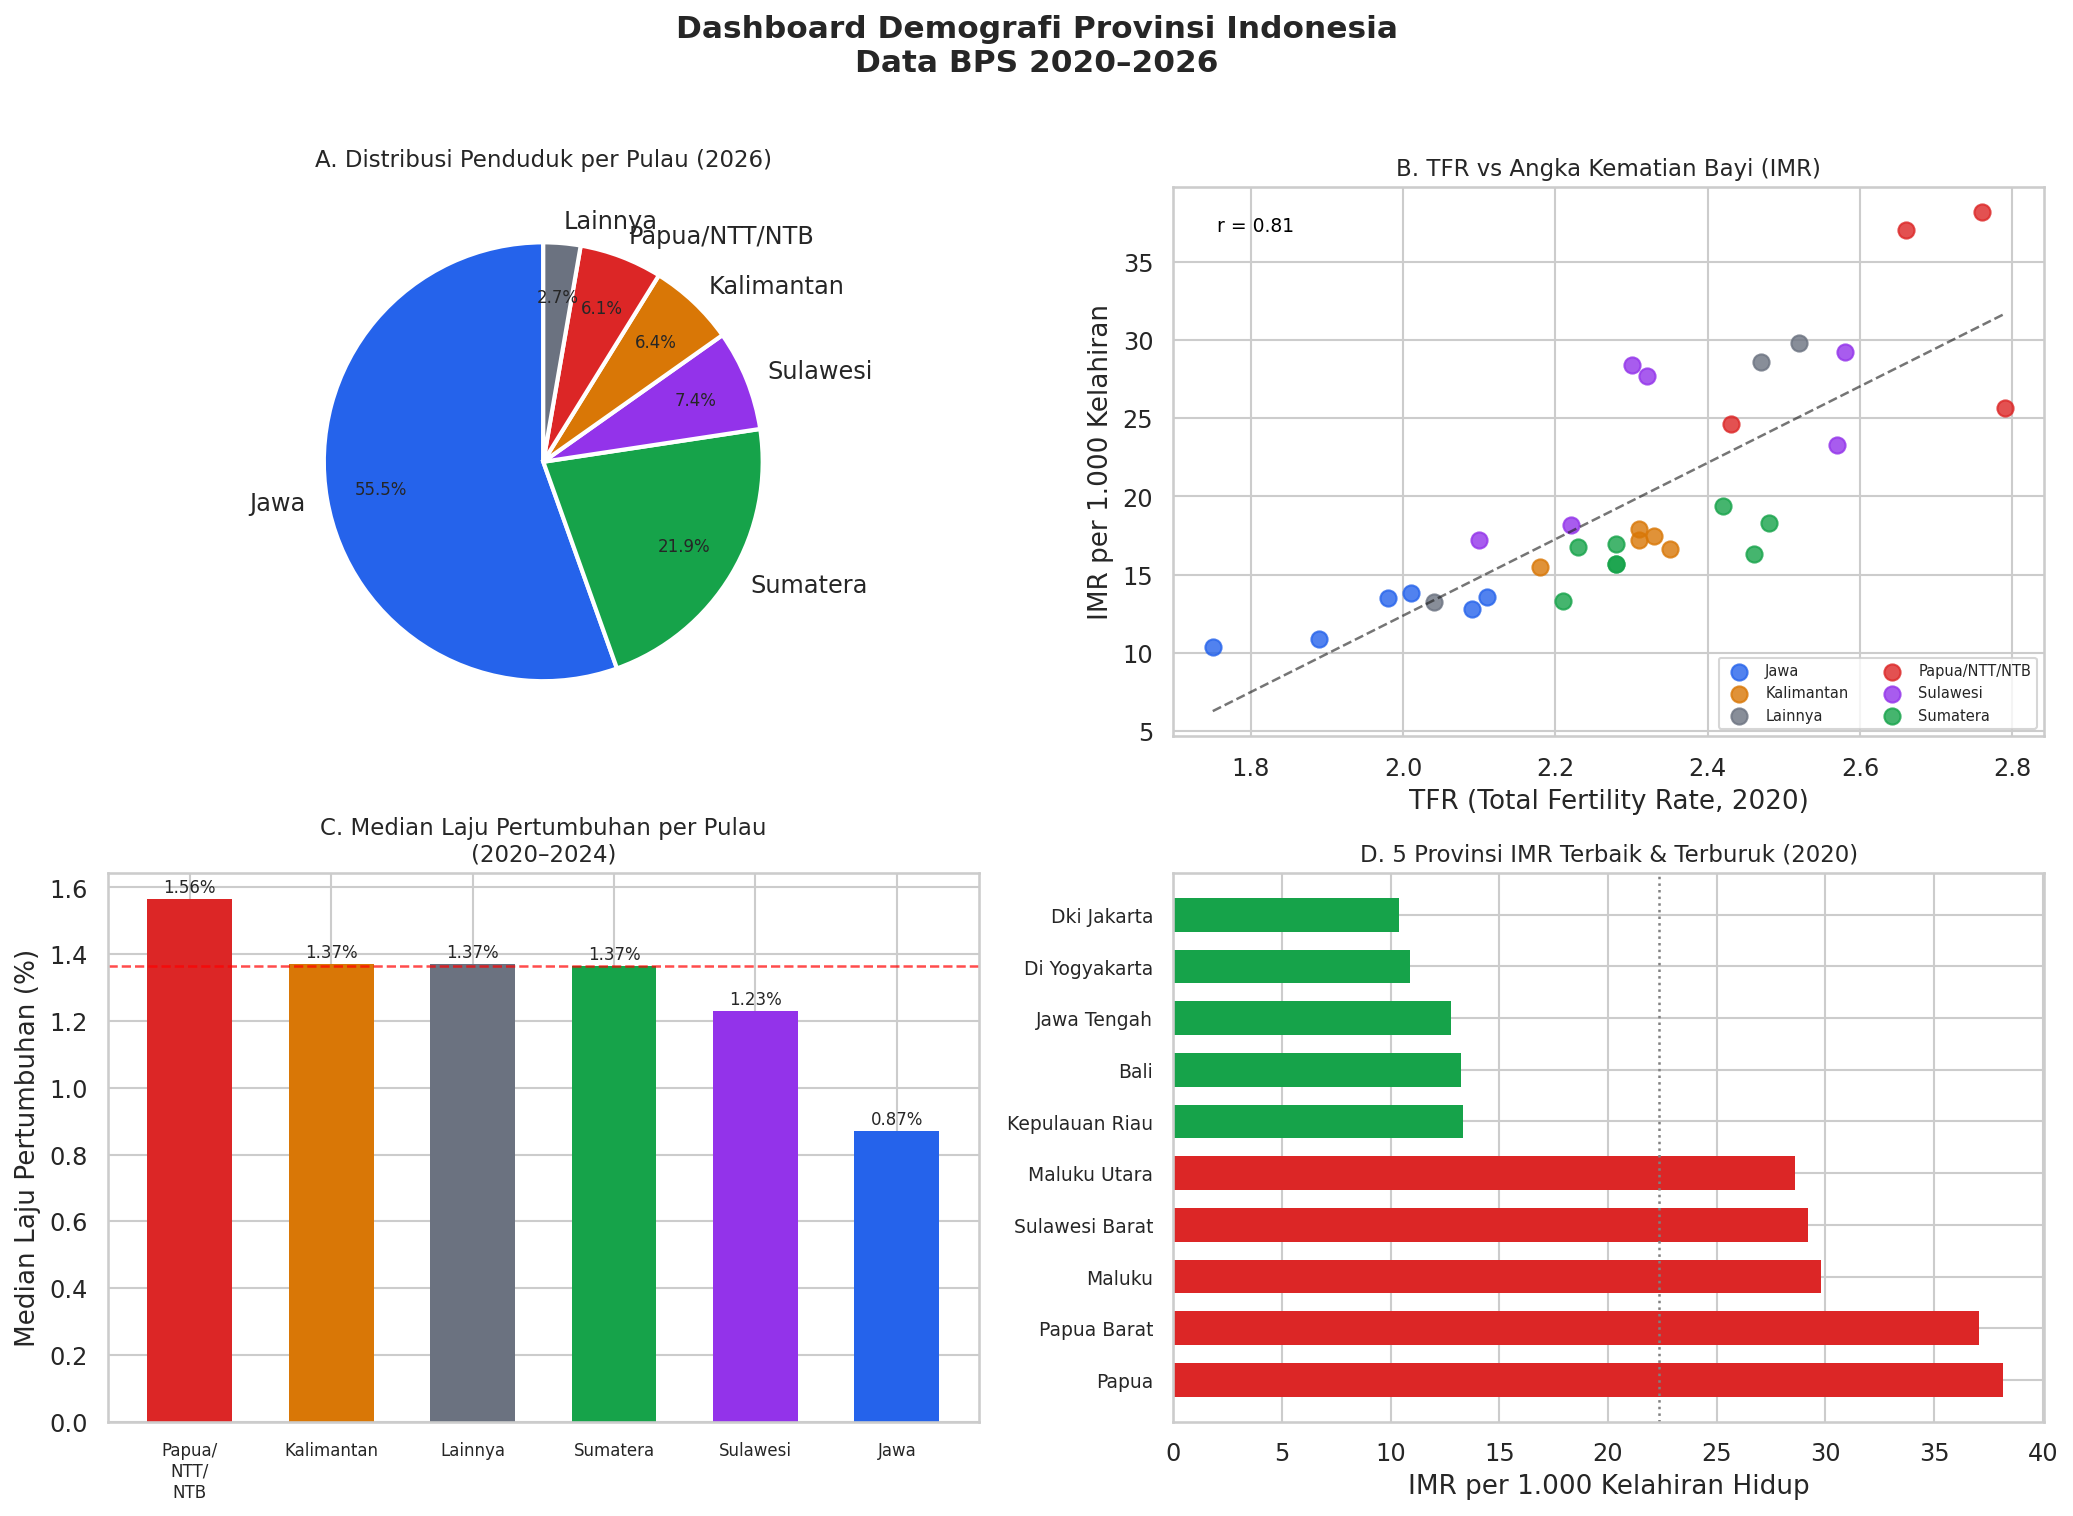

Saved: 06_dashboard_summary.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Demografi Provinsi Indonesia\nData BPS 2020–2026', fontsize=15, fontweight='bold', y=1.01)

# Panel A: Distribusi penduduk (pie)
ax = axes[0, 0]
pulau_pop = df.groupby('pulau')['distribusi_pct_2026'].sum().sort_values(ascending=False)
colors_pie = [PALETTE_PULAU.get(p,'#6B7280') for p in pulau_pop.index]
wedges, texts, autotexts = ax.pie(
    pulau_pop.values, labels=pulau_pop.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts: t.set_fontsize(8)
ax.set_title('A. Distribusi Penduduk per Pulau (2026)', fontsize=11, pad=10)

# Panel B: IMR scatter vs TFR
ax = axes[0, 1]
sp_df = df[['imr_per1000_2020','tfr_2020','pulau']].dropna()
for pulau, grp in sp_df.groupby('pulau'):
    ax.scatter(grp['tfr_2020'], grp['imr_per1000_2020'],
               color=PALETTE_PULAU.get(pulau,'#6B7280'), s=60, alpha=0.8, label=pulau)
x2, y2 = sp_df['tfr_2020'], sp_df['imr_per1000_2020']
m2, b2, r2, _, _ = stats.linregress(x2, y2)
xr2 = np.linspace(x2.min(), x2.max(), 100)
ax.plot(xr2, m2*xr2 + b2, 'k--', linewidth=1.2, alpha=0.6)
ax.text(0.05, 0.92, f'r = {r2:.2f}', transform=ax.transAxes, fontsize=9, color='black')
ax.set_xlabel('TFR (Total Fertility Rate, 2020)')
ax.set_ylabel('IMR per 1.000 Kelahiran')
ax.set_title('B. TFR vs Angka Kematian Bayi (IMR)', fontsize=11)
ax.legend(fontsize=7, ncol=2)

# Panel C: Laju pertumbuhan per pulau (bar)
ax = axes[1, 0]
laju_pulau = df.groupby('pulau')['laju_2020_2024'].median().sort_values(ascending=False)
bar_colors = [PALETTE_PULAU.get(p,'#6B7280') for p in laju_pulau.index]
ax.bar(range(len(laju_pulau)), laju_pulau.values, color=bar_colors, edgecolor='none', width=0.6)
ax.set_xticks(range(len(laju_pulau)))
ax.set_xticklabels([p.replace('/', '/\n') for p in laju_pulau.index], fontsize=8)
ax.axhline(df['laju_2020_2024'].median(), color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_ylabel('Median Laju Pertumbuhan (%)')
ax.set_title('C. Median Laju Pertumbuhan per Pulau\n(2020–2024)', fontsize=11)
for i, v in enumerate(laju_pulau.values):
    ax.text(i, v+0.02, f'{v:.2f}%', ha='center', fontsize=8)

# Panel D: Top/Bottom 5 IMR
ax = axes[1, 1]
imr_sorted = df.dropna(subset=['imr_per1000_2020']).sort_values('imr_per1000_2020')
top5_low = imr_sorted.head(5)
top5_high = imr_sorted.tail(5)
combined = pd.concat([top5_low, top5_high])
bar_c = ['#16A34A']*5 + ['#DC2626']*5
ax.barh(range(len(combined)), combined['imr_per1000_2020'], color=bar_c, edgecolor='none', height=0.65)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['provinsi'].str.title(), fontsize=9)
ax.axvline(combined['imr_per1000_2020'].mean(), color='gray', linestyle=':', linewidth=1.2)
ax.set_xlabel('IMR per 1.000 Kelahiran Hidup')
ax.set_title('D. 5 Provinsi IMR Terbaik & Terburuk (2020)', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{FIGDIR}06_dashboard_summary.png', dpi=150)
plt.show()
print('Saved: 06_dashboard_summary.png')